<a href="https://colab.research.google.com/github/PedroHS05/Prova-AM-Icoma-Naive-Bayes/blob/main/prova_31_pedro_scabelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#31: MEC | Bolsas Prouni:
Consumo: Arquivo CSV com dados de bolsas concedidas.

Alvo ($Y$): Bolsa_Integral (1) vs Bolsa_Parcial (0).

Desafio: Tratamento de strings relacionadas a notas de corte e mensalidades, transformando
variáveis qualitativas ordinais em numéricas.

##Aluno: Pedro Henrique Scabelo

#1. Importação dos dados do Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#2.Importando bibliotecas Python

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample


#3. Carregando e tratando os dados da base de Bolsas do ProUni

In [4]:
path = '/content/drive/MyDrive/provaicoma/ProuniRelatorioDadosAbertos2020.csv'
base = pd.read_csv(path, sep=';', encoding='latin1')

In [10]:
base.head()

,ANO_CONCESSAO_BOLSA,CODIGO_EMEC_IES_BOLSA,NOME_IES_BOLSA,MUNICIPIO,CAMPUS,TIPO_BOLSA,MODALIDADE_ENSINO_BOLSA,NOME_CURSO_BOLSA,NOME_TURNO_CURSO_BOLSA,CPF_BENEFICIARIO,SEXO_BENEFICIARIO,RACA_BENEFICIARIO,DATA_NASCIMENTO,BENEFICIARIO_DEFICIENTE_FISICO,REGIAO_BENEFICIARIO,UF_BENEFICIARIO,MUNICIPIO_BENEFICIARIO
0,2020,322,UNIVERSIDADE PAULISTA,IPATINGA,IPATINGA,INTEGRAL,EAD,PEDAGOGIA,CURSO A DISTÂNCIA,991.XXX.XXX-91,F,Parda,11/08/1973,N,SUDESTE,MG,GOVERNADOR VALADARES
1,2020,163,UNIVERSIDADE ESTÁCIO DE SÁ,FORTALEZA,EAD VIA CORPVS - CE,INTEGRAL,EAD,MARKETING,CURSO A DISTÂNCIA,067.XXX.XXX-01,M,Parda,13/05/1987,N,NORDESTE,CE,FORTALEZA
2,2020,17670,FACULDADE DE QUIXERAMOBIM,QUIXERAMOBIM,FACULDADE DE QUIXERAMOBIM - UNIQ,INTEGRAL,PRESENCIAL,FARMÁCIA,NOTURNO,623.XXX.XXX-27,M,Parda,23/07/2001,N,NORDESTE,CE,MOMBACA
3,2020,203,UNIVERSIDADE SÃO JUDAS TADEU,SAO PAULO,PAULISTA,PARCIAL,PRESENCIAL,DIREITO,MATUTINO,089.XXX.XXX-40,F,Branca,04/04/2003,N,NORDESTE,BA,IBITITA
4,2020,203,UNIVERSIDADE SÃO JUDAS TADEU,SAO PAULO,PAULISTA,INTEGRAL,PRESENCIAL,DIREITO,MATUTINO,173.XXX.XXX-09,F,Branca,07/12/1977,N,SUDESTE,SP,SAO PAULO


removendo dados nulos

In [5]:
base = base.dropna()

criando a variavel Alvo (Y)

In [13]:
base['Y'] = base['TIPO_BOLSA'].apply(lambda x: 1 if 'INTEGRAL' in str(x).upper() else 0)

#4.Transformação das variáveis Qualitativas ordinais e Nominais

Dando hierarquia aos turnos

In [14]:
mapeamento_turno = {'CURSO A DISTÂNCIA': 0, 'MATUTINO': 1, 'VESPERTINO': 2, 'NOTURNO': 3, 'INTEGRAL': 4}

In [15]:
base['NOME_TURNO_CURSO_BOLSA'] = base['NOME_TURNO_CURSO_BOLSA'].map(mapeamento_turno)

In [18]:
le = LabelEncoder()
colunas_nominais = ['MODALIDADE_ENSINO_BOLSA', 'SEXO_BENEFICIARIO', 'RACA_BENEFICIARIO', 'REGIAO_BENEFICIARIO']
for col in colunas_nominais: base[col] = le.fit_transform(base[col])

#5. Balanceando a Base (Downsampling)

Ao analisar a base, foi perceptível uma grande discrepância entre as classes. Para evitar o viés e manter o algoritmo eficiente, foi necessário equilibrar os dados.

In [19]:
df_parcial = base[base['Y'] == 0]

In [20]:
df_integral = base[base['Y'] == 1]

In [22]:
df_integral_downsampled = resample(df_integral, replace=False, n_samples=len(df_parcial), random_state=42)

In [23]:
base_final = pd.concat([df_integral_downsampled, df_parcial])

#6. Visualizando os Dados

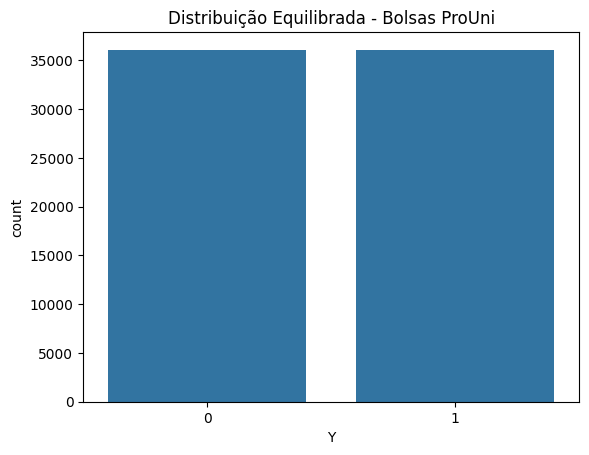

In [24]:
sns.countplot(x='Y', data=base_final)
plt.title('Distribuição Equilibrada - Bolsas ProUni')
plt.show()

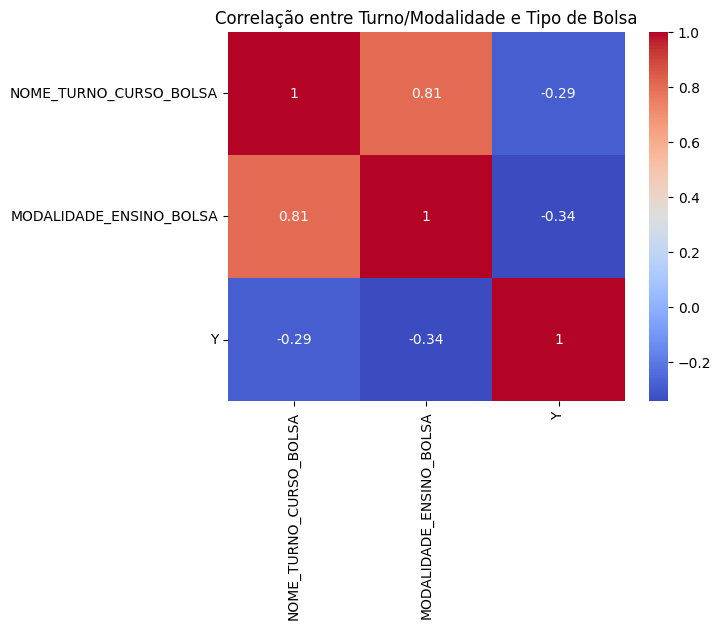

In [25]:
sns.heatmap(base_final[['NOME_TURNO_CURSO_BOLSA', 'MODALIDADE_ENSINO_BOLSA', 'Y']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlação entre Turno/Modalidade e Tipo de Bolsa')
plt.show()

#7. Ingestão Bayesiana e Normalização

In [28]:
X = base_final[['NOME_TURNO_CURSO_BOLSA', 'MODALIDADE_ENSINO_BOLSA', 'SEXO_BENEFICIARIO', 'REGIAO_BENEFICIARIO']]
y = base_final['Y']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
naive_prouni = GaussianNB()
naive_prouni.fit(X_train_scaled, y_train)

GaussianNB()

#8. Avaliando o Modelo

In [33]:
y_pred = naive_prouni.predict(X_test_scaled)

In [34]:
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")

Acurácia: 0.65


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.91      0.72     10841
           1       0.80      0.38      0.52     10808

    accuracy                           0.65     21649
   macro avg       0.70      0.65      0.62     21649
weighted avg       0.70      0.65      0.62     21649



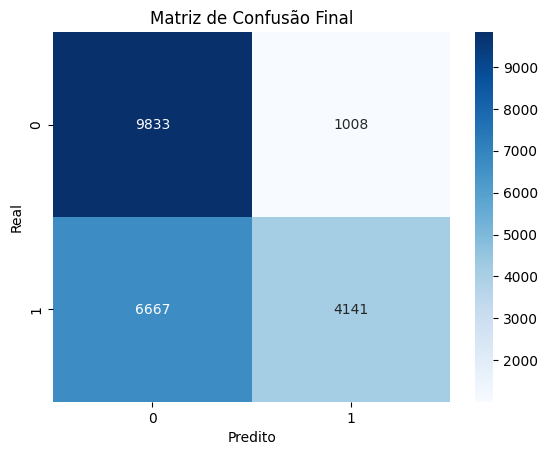

In [37]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão Final')
plt.show()